In [1]:
# ========================= START OF NOTEBOOK CODE =========================
# STEP 1 — Imports / Setup

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 80)

In [2]:
# STEP 2 — Configuration

CSV_PATH = "Electric_Vehicle_Charging_Station_Data.csv"

DATETIME_START = "Start_Date___Time"
DATETIME_END   = "End_Date___Time"
ENERGY_COL     = "Energy__kWh_"

# Output time series frequency
RESAMPLE_FREQ = "h"  # hourly

# ADF settings
ADF_REGRESSION = "c"
ADF_AUTOLAG    = None
MAXLAG = 48

# Seasonal lags to inspect in ADF/ACF/PACF
SEASONAL_LAGS = [24, 168]  # daily, weekly

# ACF/PACF plotting
NLAGS = 200  # must be >=168 to see weekly
CHECK_LAGS = [24, 168]

In [3]:
# STEP 3 — Load CSV + Basic cleaning (timestamps + energy validity)

with tqdm(total=6, desc="STEP 3: Load + clean sessions", unit="step") as pbar:
    df_raw = pd.read_csv(CSV_PATH)
    df = df_raw.copy()
    pbar.update(1)

    # Parse datetimes
    df[DATETIME_START] = pd.to_datetime(df[DATETIME_START], format="mixed")
    df[DATETIME_END]   = pd.to_datetime(df[DATETIME_END], format="mixed")
    pbar.update(1)

    # Drop missing timestamps
    df = df.dropna(subset=[DATETIME_START, DATETIME_END])
    pbar.update(1)

    # Numeric energy
    df[ENERGY_COL] = pd.to_numeric(df[ENERGY_COL])
    df = df.dropna(subset=[ENERGY_COL])
    pbar.update(1)

    # Remove non-positive energy and invalid end<start
    df = df[df[ENERGY_COL] > 0]
    df = df[df[DATETIME_END] > df[DATETIME_START]]  # strictly > to avoid zero duration
    pbar.update(1)

    # Sort
    df = df.sort_values(DATETIME_START).reset_index(drop=True)
    pbar.update(1)

print("Clean session rows:", len(df))
df[[DATETIME_START, DATETIME_END, ENERGY_COL]].head()
df[[DATETIME_START, DATETIME_END, ENERGY_COL]].tail()

STEP 3: Load + clean sessions: 100%|██████████| 6/6 [00:07<00:00,  1.32s/step]

Clean session rows: 131968


,Start_Date___Time,End_Date___Time,Energy__kWh_
131963,2023-11-30 19:11:00,2023-11-30 20:55:00,5.757
131964,2023-11-30 19:58:00,2023-11-30 20:10:00,1.194
131965,2023-11-30 20:01:00,2023-11-30 20:21:00,1.899
131966,2023-11-30 21:03:00,2023-11-30 21:31:00,1.499
131967,2023-11-30 23:27:00,2023-12-01 09:02:00,17.755


In [4]:
df[[DATETIME_START, DATETIME_END, ENERGY_COL]].head(20)

,Start_Date___Time,End_Date___Time,Energy__kWh_
0,2018-01-01 17:49:00,2018-01-01 19:52:00,6.504
1,2018-01-01 17:49:00,2018-01-01 19:52:00,6.504
2,2018-01-02 08:52:00,2018-01-02 09:16:00,2.481
3,2018-01-02 08:52:00,2018-01-02 09:16:00,2.481
4,2018-01-02 21:11:00,2018-01-03 06:23:00,15.046
5,2018-01-02 21:11:00,2018-01-03 06:23:00,15.046
6,2018-01-03 09:19:00,2018-01-03 11:14:00,6.947
7,2018-01-03 09:19:00,2018-01-03 11:14:00,6.947
8,2018-01-03 14:13:00,2018-01-03 14:30:00,1.800
9,2018-01-03 14:13:00,2018-01-03 14:30:00,1.800


In [5]:
df[[DATETIME_START, DATETIME_END, ENERGY_COL]].tail(10)

,Start_Date___Time,End_Date___Time,Energy__kWh_
131958,2023-11-30 18:22:00,2023-12-05 04:12:00,15.303
131959,2023-11-30 18:41:00,2023-11-30 20:26:00,0.491
131960,2023-11-30 18:51:00,2023-11-30 19:46:00,5.573
131961,2023-11-30 18:56:00,2023-11-30 21:11:00,8.628
131962,2023-11-30 18:57:00,2023-11-30 21:17:00,13.138
131963,2023-11-30 19:11:00,2023-11-30 20:55:00,5.757
131964,2023-11-30 19:58:00,2023-11-30 20:10:00,1.194
131965,2023-11-30 20:01:00,2023-11-30 20:21:00,1.899
131966,2023-11-30 21:03:00,2023-11-30 21:31:00,1.499
131967,2023-11-30 23:27:00,2023-12-01 09:02:00,17.755


In [6]:
# STEP 4 — Builad hourly demand series using overlap-based redistribution (best method)
# Each session's kWh is distributed proportionally into every hour it overlaps.

def distribute_energy_to_hours(df: pd.DataFrame,
                               start_col: str,
                               end_col: str,
                               energy_col: str) -> pd.Series:
    """
    Returns hourly time series (kWh per hour) where each session's energy is distributed
    across the hours it overlaps, proportional to overlap duration.
    """
    # Accumulator (dict is faster than repeatedly appending to a Series)
    hourly_kwh = {}

    iterator = tqdm(df.itertuples(index=False), total=len(df), desc="STEP 4: Redistributing sessions", unit="session")

    for row in iterator:
        start = getattr(row, start_col)
        end   = getattr(row, end_col)
        e_kwh = getattr(row, energy_col)

        # duration in seconds
        dur_s = (end - start).total_seconds()
        if dur_s <= 0:
            continue

        # constant power assumption during session (kWh per second)
        # energy allocated by time overlap
        # power_kwh_per_s = e_kwh / dur_s
        power = e_kwh / dur_s

        # hour boundaries we will visit
        h = start.floor("h")
        last_h = end.floor("h")

        # iterate through each hour block that overlaps the session
        while h <= last_h:
            h_next = h + pd.Timedelta(hours=1)

            overlap_start = max(start, h)
            overlap_end   = min(end, h_next)

            overlap_s = (overlap_end - overlap_start).total_seconds()
            if overlap_s > 0:
                hourly_kwh[h] = hourly_kwh.get(h, 0.0) + power * overlap_s

            h = h_next

    # Convert to Series and sort
    y = pd.Series(hourly_kwh).sort_index()
    y.index = pd.to_datetime(y.index)

    # Ensure continuous hourly index
    full_index = pd.date_range(start=y.index.min().floor("h"),
                               end=y.index.max().floor("h"),
                               freq="h")
    y = y.reindex(full_index, fill_value=0.0)
    y.name = "demand_kWh"

    return y

y = distribute_energy_to_hours(df, DATETIME_START, DATETIME_END, ENERGY_COL)

print("\nHourly demand series (overlap redistributed):")
print(" Start:", y.index.min())
print(" End:  ", y.index.max())
print(" N:    ", len(y))
print(" Mean: ", float(y.mean()))
print(" Std:  ", float(y.std()))
y.head(10)


OUTPUT_PATH = "cleandata.csv"

df_clean = y.to_frame()

df_clean = df_clean.reset_index().rename(columns={"index": "timestamp"})

df_clean.to_csv(OUTPUT_PATH, index=False)

print(f"\n Cleaned hourly dataset saved to: {OUTPUT_PATH}")
print("Rows:", len(df_clean))
print(df_clean.head())

STEP 4: Redistributing sessions: 100%|██████████| 131968/131968 [00:04<00:00, 31497.64session/s]



Hourly demand series (overlap redistributed):
 Start: 2018-01-01 17:00:00
 End:   2023-12-05 04:00:00
 N:     51924
 Mean:  24.125770761112395
 Std:   27.967085158162128

 Cleaned hourly dataset saved to: cleandata.csv
Rows: 51924
            timestamp  demand_kWh
0 2018-01-01 17:00:00    1.163317
1 2018-01-01 18:00:00    6.345366
2 2018-01-01 19:00:00    5.499317
3 2018-01-01 20:00:00    0.000000
4 2018-01-01 21:00:00    0.000000


In [7]:
# df_clean.index = pd.to_datetime(df_clean["timestamp"])
# df_clean = df_clean.drop(columns=["timestamp"])

df_clean

,timestamp,demand_kWh
0,2018-01-01 17:00:00,1.163317
1,2018-01-01 18:00:00,6.345366
2,2018-01-01 19:00:00,5.499317
3,2018-01-01 20:00:00,0.000000
4,2018-01-01 21:00:00,0.000000
...,...,...
51919,2023-12-05 00:00:00,0.144595
51920,2023-12-05 01:00:00,0.144595
51921,2023-12-05 02:00:00,0.144595
51922,2023-12-05 03:00:00,0.144595


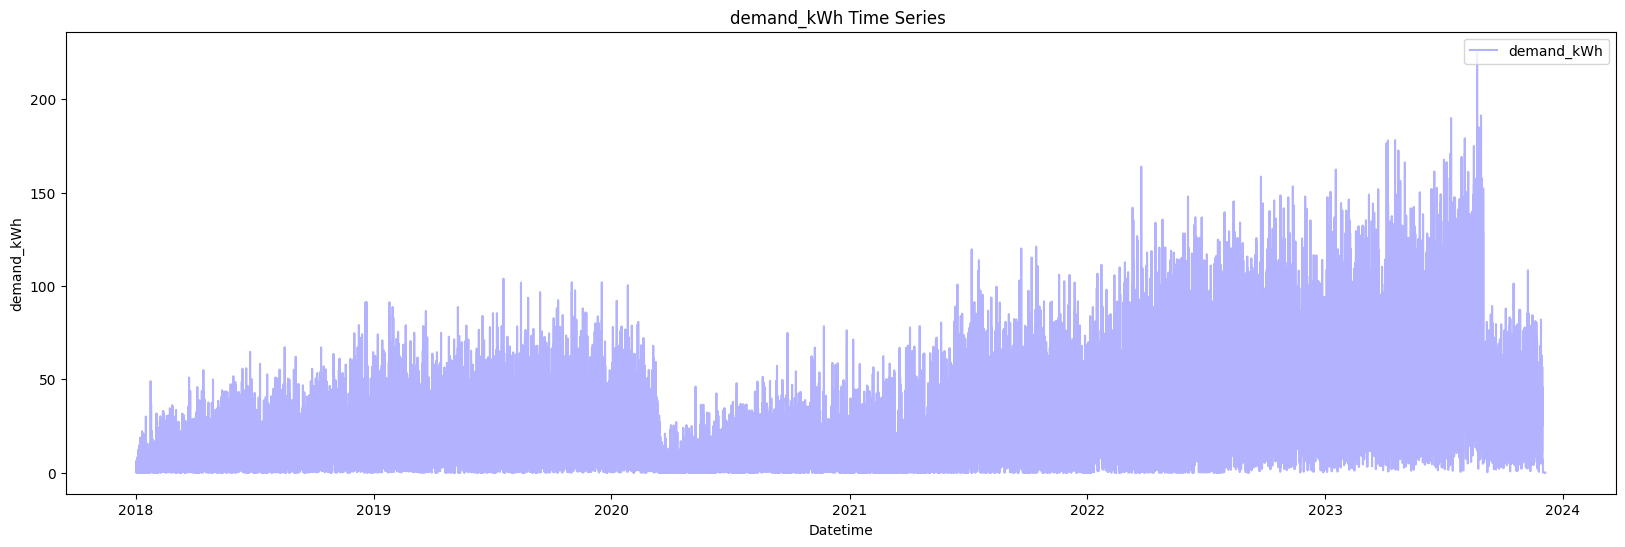

In [20]:
plt.figure(figsize=(20, 6))
plt.plot(df_clean.index, df_clean['demand_kWh'], label='demand_kWh', color='blue', alpha=0.3)
plt.xlabel('Datetime')
plt.ylabel('demand_kWh')
plt.title('demand_kWh Time Series ')
plt.legend(loc='upper right')
plt.show()

In [8]:
adf_result = adfuller(df_clean['demand_kWh'])
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

ADF Statistic: -7.662368040230906
p-value: 1.6754835423741447e-11


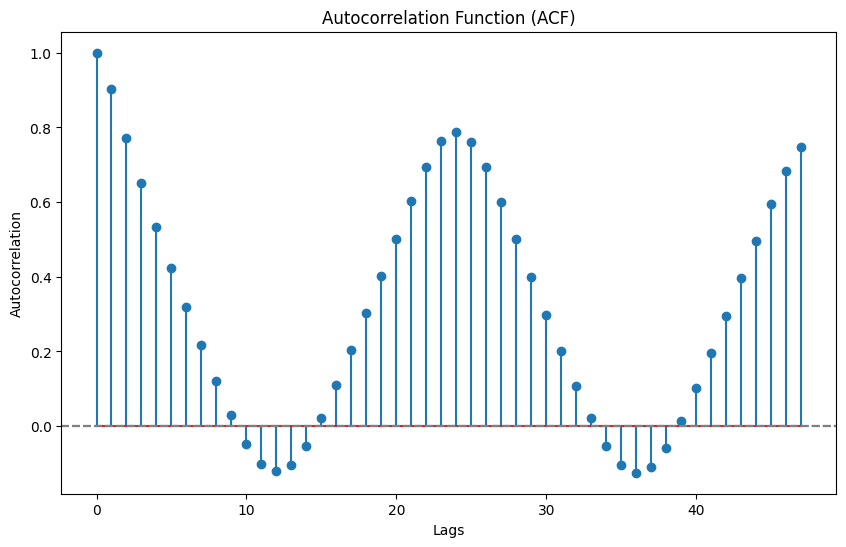

In [9]:
# Compute ACF values
acf_values = acf(df_clean['demand_kWh'], fft=True)

# Create lags for the x-axis
lags = range(len(acf_values))

# Plot the ACF values manually
plt.figure(figsize=(10, 6))
plt.stem(lags, acf_values)  # Stem plot for spikes
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF)')

# Add a horizontal line for significance thresholds (e.g., 95% confidence interval)
plt.axhline(y=0, linestyle='--', color='gray')
plt.axhline(y=1.96 / (len(df_clean['demand_kWh']**0.5)), linestyle='--', color='gray')  # Upper bound
plt.axhline(y=-1.96 / (len(df_clean['demand_kWh']**0.5)), linestyle='--', color='gray')  # Lower bound

plt.show()

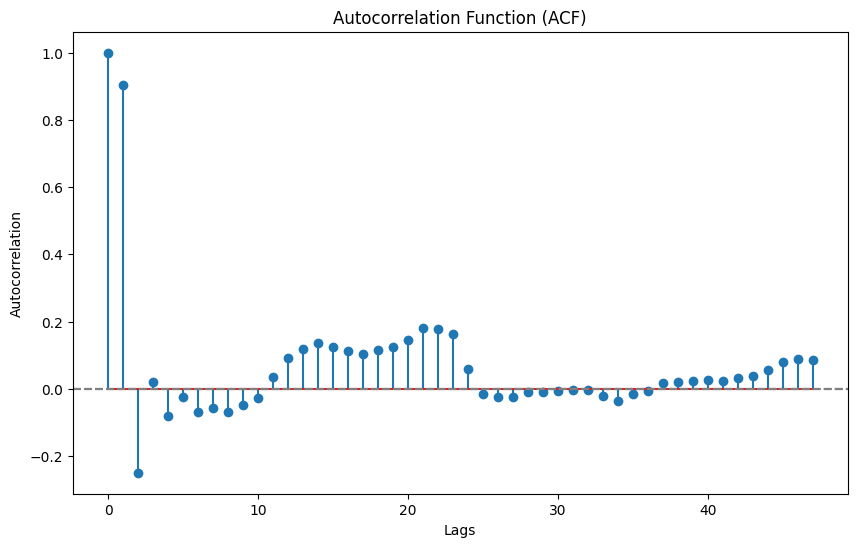

In [11]:
# Compute ACF values
acf_values = pacf(df_clean['demand_kWh'])

# Create lags for the x-axis
lags = range(len(acf_values))

# Plot the ACF values manually
plt.figure(figsize=(10, 6))
plt.stem(lags, acf_values)  # Stem plot for spikes
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF)')

# Add a horizontal line for significance thresholds (e.g., 95% confidence interval)
plt.axhline(y=0, linestyle='--', color='gray')
plt.axhline(y=1.96 / (len(df_clean['demand_kWh']**0.5)), linestyle='--', color='gray')  # Upper bound
plt.axhline(y=-1.96 / (len(df_clean['demand_kWh']**0.5)), linestyle='--', color='gray')  # Lower bound

plt.show()

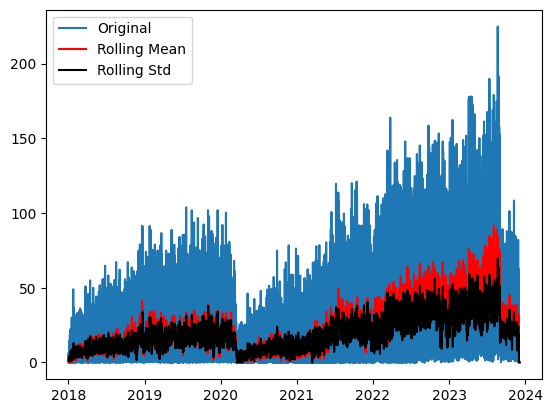

In [26]:
rolling_mean = df_clean['demand_kWh'].rolling(window=24).mean()
rolling_std = df_clean['demand_kWh'].rolling(window=24).std()

plt.plot(df_clean['demand_kWh'], label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='black', label='Rolling Std')
plt.legend()
plt.show()

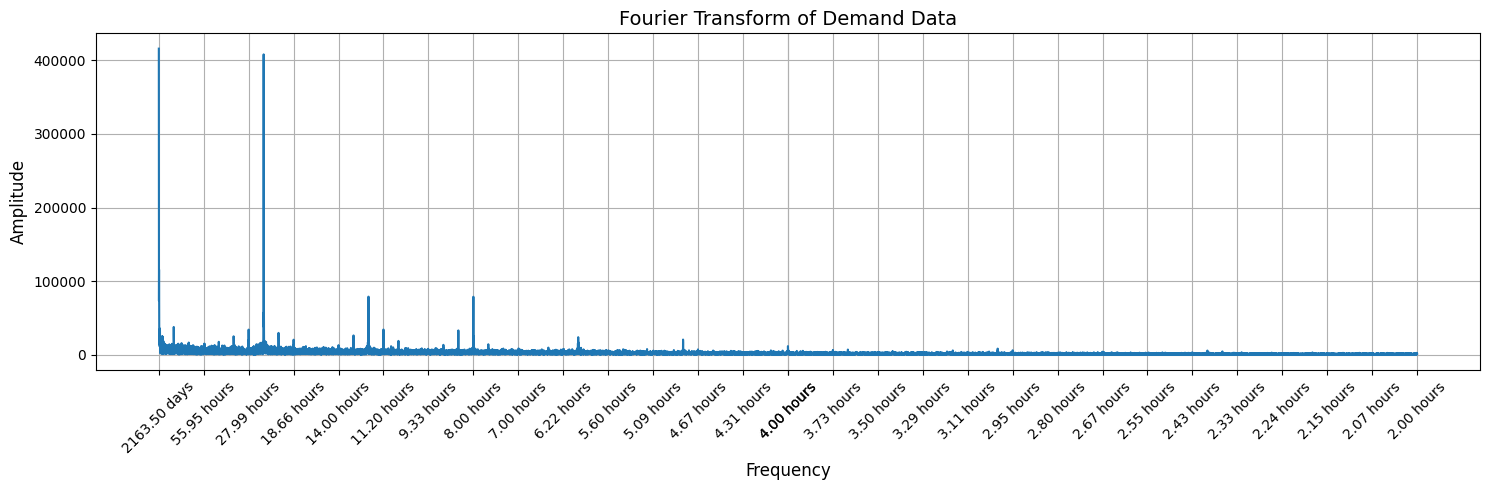

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Perform the FFT on the 'LMP' data
GHI_fft = np.fft.fft(df_clean['demand_kWh'])

# Calculate the number of samples
n = len(df_clean)

# Keep the original sampling interval (10 minutes)
sampling_interval = 1  # In hours, for 10-minute intervals, it's actually 1/6 hours

# Calculate frequencies
frequencies = np.fft.fftfreq(n, d=sampling_interval)

# Filter positive frequencies and their corresponding FFT values
positive_frequencies = frequencies[frequencies > 0]
positive_fft = np.abs(GHI_fft[frequencies > 0])

# Find the dominant frequency and its amplitude
dominant_freq_index = np.argmax(positive_fft)
dominant_frequency = positive_frequencies[dominant_freq_index]
dominant_amplitude = positive_fft[dominant_freq_index]

# Create the plot
plt.figure(figsize=(15, 5))
plt.plot(positive_frequencies, positive_fft)

# Update the plot title and labels
plt.title('Fourier Transform of Demand Data', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)

# Create custom x-ticks with emphasis on the left side
left_num_ticks = 15  # Increased number of ticks on the left
right_num_ticks = 15   # Number of ticks on the right

# Get indices for ticks
left_ticks_indices = np.linspace(0, len(positive_frequencies) // 2, left_num_ticks, dtype=int)
right_ticks_indices = np.linspace(len(positive_frequencies) // 2, len(positive_frequencies) - 1, right_num_ticks, dtype=int)

# Combine indices
x_ticks_indices = np.concatenate([left_ticks_indices, right_ticks_indices])

# Get frequencies for the ticks
x_ticks = positive_frequencies[x_ticks_indices]

# Set x-ticks and their labels
tick_labels = []
for tick in x_ticks:
    time_period = (1 / tick)
    if time_period / 144 >= 1:  # Convert to days if greater than or equal to 1 day
        tick_labels.append(f"{time_period / 24:.2f} days")
    else:  # Otherwise, show in hours
        tick_labels.append(f"{time_period / 1 :.2f} hours")

# Adjust the ticks
plt.xticks(x_ticks, tick_labels, rotation=45)  # Rotate labels for better readability

# Calculate padding for x-axis (e.g., 10% padding)
padding_ratio = 0.1
x_min = np.min(positive_frequencies)
x_max = np.max(positive_frequencies) / 25  # Adjusted x-axis range
x_padding = (x_max - x_min) * padding_ratio

# Set x-axis limits with padding
# plt.xlim(left=x_min - x_padding, right=x_max + x_padding)

plt.grid(True)
plt.tight_layout()  # Adjust layout to fit labels
plt.show()

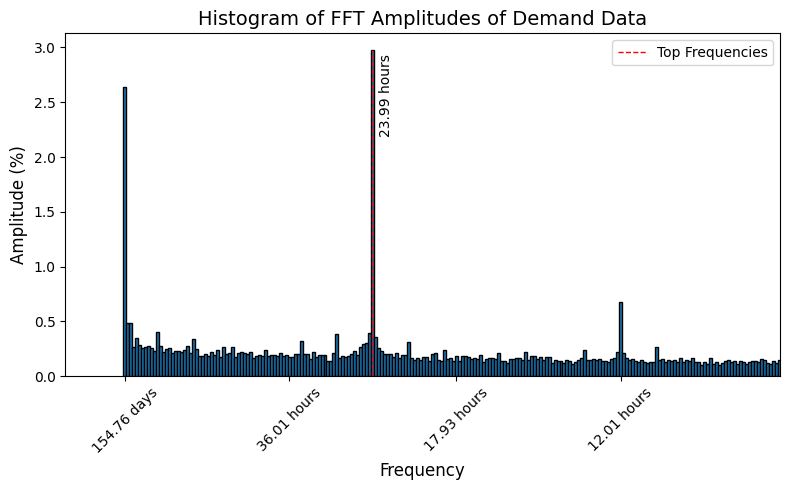

In [39]:
# Calculate total amplitude for percentage conversion
total_amplitude = np.sum(positive_fft)

# Convert the amplitudes to percentages
positive_fft_percentage = (positive_fft / total_amplitude) * 100

# Define bin size and bin the data
bin_size = 1000  # Number of bins, adjust this value as needed
hist, bin_edges = np.histogram(positive_frequencies, bins=bin_size, weights=positive_fft_percentage)

# Get the bin centers for plotting
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create the histogram plot
plt.figure(figsize=(8, 5))
plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', align='center')

# Update the plot title and labels
plt.title('Histogram of FFT Amplitudes of Demand Data', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Amplitude (%)', fontsize=12)  # Updated ylabel to reflect percentage

# Create custom x-ticks with emphasis on the left side
left_num_ticks = 10  # Increased number of ticks on the left
right_num_ticks = 5   # Number of ticks on the right

# Get indices for ticks
left_ticks_indices = np.linspace(0, len(bin_centers) // 2, left_num_ticks, dtype=int)
right_ticks_indices = np.linspace(len(bin_centers) // 2, len(bin_centers) - 1, right_num_ticks, dtype=int)

# Combine indices
x_ticks_indices = np.concatenate([left_ticks_indices, right_ticks_indices])

# Get frequencies for the ticks
x_ticks = bin_centers[x_ticks_indices]

# Set x-ticks and their labels
tick_labels = []
for tick in x_ticks:
    time_period = (1 / tick)
    if time_period / 144 >= 1:  # Convert to days if greater than or equal to 1 day
        tick_labels.append(f"{time_period / 24:.2f} days")
    else:  # Otherwise, show in hours
        tick_labels.append(f"{time_period / 1 :.2f} hours")

# Adjust the ticks
plt.xticks(x_ticks, tick_labels, rotation=45)  # Rotate labels for better readability

# Calculate padding for x-axis (e.g., 10% padding)
padding_ratio = 0.1
x_min = np.min(bin_centers)
x_max = np.max(bin_centers) / 5  # Adjusted x-axis range
x_padding = (x_max - x_min) * padding_ratio

# Set x-axis limits with padding
plt.xlim(left=x_min - x_padding, right=x_max + x_padding)

# Locate the top frequency per tick range
top_frequencies = []
top_amplitudes = []
top_tick_labels = []

for i in range(len(x_ticks) - 1):
    # Define the tick range
    tick_min = x_ticks[i]
    tick_max = x_ticks[i + 1]
    
    # Find the indices of frequencies that fall within this tick range
    in_range_indices = np.where((positive_frequencies >= tick_min) & (positive_frequencies < tick_max))[0]
    
    if len(in_range_indices) > 0:
        # Find the index of the maximum amplitude in this range
        max_index = in_range_indices[np.argmax(positive_fft_percentage[in_range_indices])]
        
        # Get the frequency and amplitude for this maximum
        top_frequency = positive_frequencies[max_index]
        top_amplitude = positive_fft_percentage[max_index]
        
        # Convert the top frequency to the time period (in hours or days)
        top_time_period = (1 / top_frequency)
        if top_time_period / 24 >= 1:
            time_period_str = f"{top_time_period / 24:.2f} day"
        else:
            time_period_str = f"{top_time_period/ 1:.2f} hours"
        
        # Store the top frequency and amplitude for plotting
        top_frequencies.append(top_frequency)
        top_amplitudes.append(top_amplitude)
        top_tick_labels.append(time_period_str)

# Specify indices of top frequencies you want to display (e.g., only display first three)
selected_indices = [1]  # Change this list based on which frequencies you want to show

# Get the maximum y value for full-height lines
max_y_value = np.max(hist)

# Plot vertical lines for the selected frequencies
for i in selected_indices:
    freq = top_frequencies[i]
    plt.vlines(x=freq, ymin=0, ymax=max_y_value, color='red', linewidth=1, linestyles='dashed')  # Vertical line

    # Annotate the tick interval labels at the top of each line with vertical text
    plt.annotate(top_tick_labels[i], (freq, max_y_value - (max_y_value * .30)), textcoords="offset points", xytext=(5, 10), ha='left', rotation=90)

# Add a legend to the plot
plt.legend(['Top Frequencies'],loc='upper right')

plt.tight_layout()  # Adjust layout to fit labels
plt.show()